In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm

plt.style.use("default")

# Introduction

This notebook analyzes the relationship between gravitational wave detections and scientific publication activity from 2010–2024. The analysis evaluates detection growth, detector expansion effects, publication dynamics, control-group comparison, and lag relationships between detections and research output.

In [149]:
current_data_lim = "O4a"

# Make Observation runs dataframe, usefull for later analysis and visualizations to understand the context of the detections and publications.
## Note: Currenlty only O1 - 04a event data has been published, but the rest of the O4 runs are included for future use when the data is released.
runs = pd.DataFrame({
    "Run": ["O1", "O2", "O3a", "O3b", "O4a", "O4b", "O4c1", "O4c2"],
    "Start Date": ["2015-09-12", "2016-11-30", "2019-04-01", "2019-11-01", "2023-05-24", "2024-04-10", "2025-01-28", "2025-06-12"],
    "End Date": ["2016-01-19", "2017-08-25", "2019-09-30", "2020-03-27", "2024-01-16", "2025-01-28", "2025-03-31", "2025-11-18"],
    "Detectors": [2, 3, 3, 3, 3, 4, 4, 4]
})
runs["Start Date"] = pd.to_datetime(runs["Start Date"])
runs["End Date"] = pd.to_datetime(runs["End Date"])
runs["Detectors"] = runs["Detectors"].astype(int)


In [150]:
# Load the processed data for gravitational wave detections and publications
gw_events = pd.read_csv(r"../01 - Data/processed/gw_monthly.csv")
gw_papers = pd.read_csv(r"../01 - Data/processed/gw_papers_monthly.csv")
astro_papers = pd.read_csv(r"../01 - Data/processed/astro_papers_monthly.csv")

gw_events["Month"] = pd.to_datetime(gw_events["Month"])
gw_papers["Month"] = pd.to_datetime(gw_papers["Month"])
astro_papers["Month"] = pd.to_datetime(astro_papers["Month"])

In [151]:
gw_events.head()

,Month,Event Count,Avg Detectors,Cumulative Detections,Time Index
0,2015-09-01,1,2,1,0
1,2015-10-01,1,2,2,1
2,2015-11-01,0,2,2,2
3,2015-12-01,1,2,3,3
4,2016-01-01,0,2,3,4


In [152]:
gw_papers.head()

,Month,Paper Count,Avg Authors,Cumulative Papers,Time Index
0,2010-01-01,38,21,38,0
1,2010-02-01,38,9,76,1
2,2010-03-01,52,31,128,2
3,2010-04-01,50,3,178,3
4,2010-05-01,52,3,230,4


In [153]:
astro_papers.head()

,Month,Paper Count,Avg Authors,Cumulative Papers,Time Index
0,2010-01-01,1018,7,1018,0
1,2010-02-01,959,5,1977,1
2,2010-03-01,1085,5,3062,2
3,2010-04-01,1020,6,4082,3
4,2010-05-01,1139,10,5221,4


In [154]:
master = (
    gw_events[["Month", "Event Count", "Avg Detectors"]]
    .merge(gw_papers[["Month", "Paper Count"]], on="Month", how="outer")
    .merge(astro_papers[["Month", "Paper Count"]], on="Month", how="outer", suffixes=("_gw", "_astro"))
)

master.rename(columns={
    "Paper Count_gw": "GW Papers",
    "Paper Count_astro": "Astro Papers"
}, inplace=True)

master["Avg Detectors"] = master["Avg Detectors"].ffill()
master.fillna(0, inplace=True)

master["Avg Detectors"] = master["Avg Detectors"].astype(int)
master["Event Count"] = master["Event Count"].astype(int)

# Some helper columns for later analysis and visualizations
master["GW Share"] = master["GW Papers"] / master["Astro Papers"]
master["GW Share"] = master["GW Share"].replace([np.inf, -np.inf], 0)

master["Post_2015"] = (master["Month"] >= "2015-09-01").astype(int)
master["Time Index"] = range(len(master))

# Function to classify each month into Baseline, Active, or Post_Run phases based on the observation runs
def classify_phase(date, runs):
    for _, row in runs.iterrows():
        if row["Start Date"] <= date <= row["End Date"]:
            return "Active"
        elif row["End Date"] < date <= row["End Date"] + pd.DateOffset(months=6):
            return "Post_Run"
    return "Baseline"

master["Phase"] = master["Month"].apply(lambda d: classify_phase(d, runs))

master

,Month,Event Count,Avg Detectors,GW Papers,Astro Papers,GW Share,Post_2015,Time Index,Phase
0,2010-01-01,0,0,38,1018,0.037328,0,0,Baseline
1,2010-02-01,0,0,38,959,0.039625,0,1,Baseline
2,2010-03-01,0,0,52,1085,0.047926,0,2,Baseline
3,2010-04-01,0,0,50,1020,0.049020,0,3,Baseline
4,2010-05-01,0,0,52,1139,0.045654,0,4,Baseline
...,...,...,...,...,...,...,...,...,...
175,2024-08-01,0,3,168,1370,0.122628,1,175,Active
176,2024-09-01,0,3,195,1696,0.114976,1,176,Active
177,2024-10-01,0,3,248,1922,0.129032,1,177,Active
178,2024-11-01,0,3,203,1632,0.124387,1,178,Active


# Detection Growth Over Time

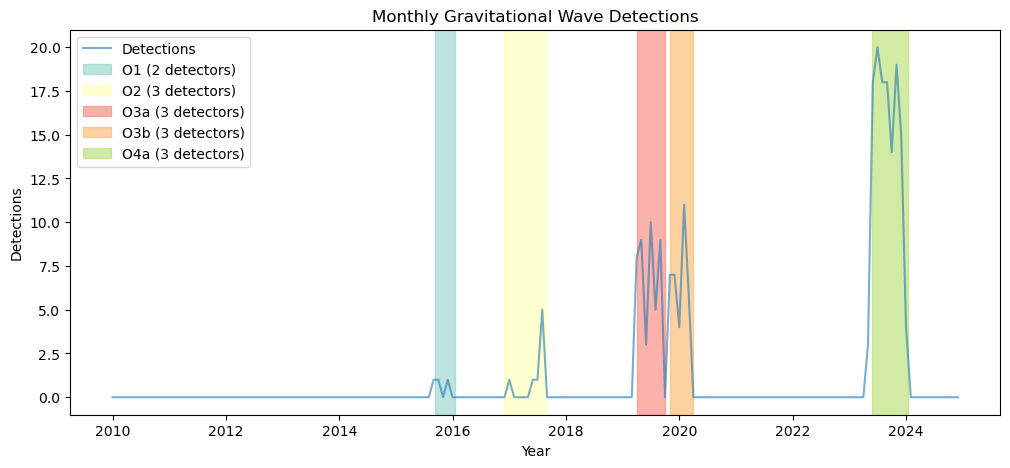

In [155]:
plt.figure(figsize=(12,5))
plt.plot(master["Month"], master["Event Count"], alpha=0.6, label="Detections")

colors = plt.cm.Set3(np.linspace(0, 1, len(runs)))
for idx, (_, row) in enumerate(runs.iterrows()):
    if row['Run'] <= current_data_lim:
        plt.axvspan(row["Start Date"], row["End Date"], alpha=0.6, color=colors[idx], label=f"{row['Run']} ({row['Detectors']} detectors)")
plt.title("Monthly Gravitational Wave Detections")
plt.legend(loc="upper left")
plt.xlabel("Year")
plt.ylabel("Detections")
plt.show()

With each new detection run, the number of gravitational wave detections has increased significantly. The first detection in 2015 marked a major milestone, leading to a surge in both detections and related research. Subsequent runs have continued to expand our understanding of the universe, with more sensitive detectors and improved data analysis techniques contributing to a steady increase in detection rates.

# Detector Expansion Impact

In [156]:
two_det = master[master["Avg Detectors"] == 2]["Event Count"]
three_det = master[master["Avg Detectors"] == 3]["Event Count"]

t_stat, p_val = ttest_ind(two_det, three_det, equal_var=False)

print("T-stat:", round(t_stat, 2))
print("P-value:", round(p_val, 5))

T-stat: -3.98
P-value: 0.00013


In [157]:
X = master[["Avg Detectors", "Time Index"]]
X = sm.add_constant(X)

y = master["Event Count"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Event Count   R-squared:                       0.110
Model:                            OLS   Adj. R-squared:                  0.100
Method:                 Least Squares   F-statistic:                     10.92
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           3.36e-05
Time:                        16:13:26   Log-Likelihood:                -484.38
No. Observations:                 180   AIC:                             974.8
Df Residuals:                     177   BIC:                             984.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.0006      0.554     -1.805

A simple mean comparison suggests significantly higher detection rates during multi-detector observation runs (t = -3.98, p < 0.001). However, when controlling for underlying time trends in a regression framework, detector count is no longer statistically significant. This indicates that the apparent effect of detector expansion largely reflects broader temporal improvements in detection capability rather than discrete jumps associated with network size.

In [158]:
master["Lag1"] = master["Event Count"].shift(1)
master_lag = master.dropna(subset=["Lag1"])

X = master_lag[["Avg Detectors", "Time Index", "Lag1"]]
X = sm.add_constant(X)

y = master_lag["Event Count"]

model_lag = sm.OLS(y, X).fit()

print(model_lag.summary())

                            OLS Regression Results                            
Dep. Variable:            Event Count   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.671
Method:                 Least Squares   F-statistic:                     121.9
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           1.16e-42
Time:                        16:13:26   Log-Likelihood:                -391.56
No. Observations:                 179   AIC:                             791.1
Df Residuals:                     175   BIC:                             803.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.1520      0.344     -0.442

Adding a one-month lag of detection counts substantially improved model fit (R² = 0.676) and resolved autocorrelation (Durbin–Watson ≈ 2). The strong persistence coefficient (coeff = 0.80, p < 0.001) indicates that detection rates evolve gradually over time. Once persistence is accounted for, detector count does not exhibit a statistically significant independent effect.

# GW Publication Trend

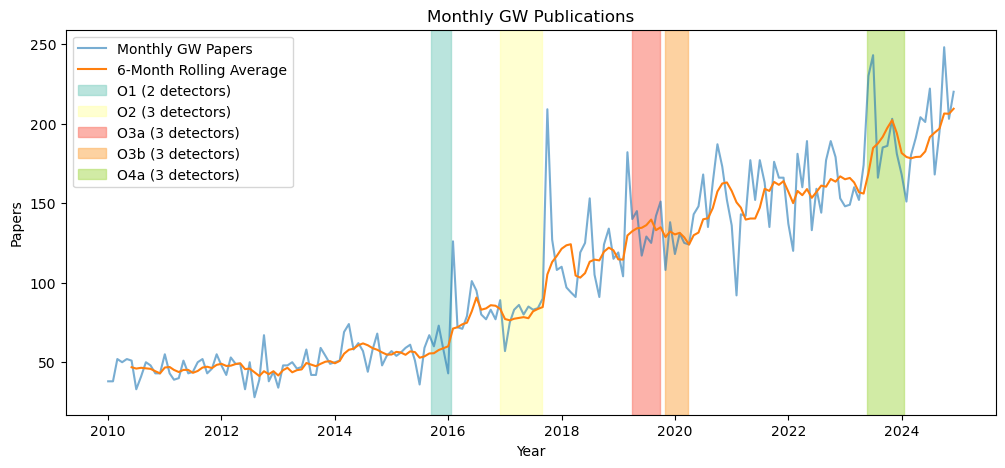

In [159]:
master["Rolling GW Papers"] = master["GW Papers"].rolling(6).mean()

plt.figure(figsize=(12,5))
plt.plot(master["Month"], master["GW Papers"], alpha=0.6, label="Monthly GW Papers")
plt.plot(master["Month"], master["Rolling GW Papers"], label="6-Month Rolling Average")
colors = plt.cm.Set3(np.linspace(0, 1, len(runs)))
for idx, (_, row) in enumerate(runs.iterrows()):
    if row['Run'] <= current_data_lim:
        plt.axvspan(row["Start Date"], row["End Date"], alpha=0.6, color=colors[idx], label=f"{row['Run']} ({row['Detectors']} detectors)")
plt.title("Monthly GW Publications")
plt.legend()
plt.xlabel("Year")
plt.ylabel("Papers")
plt.show()

We see the monthly publication trend for GW papers, with a 6-month rolling average to smooth out short-term fluctuations. The plot shows a clear upward trend in publications over time, with noticeable increases following major detection runs, with the expection of O3 runs which did not show a significant increase in publications, possibly due to the ongoing pandemic at the time. The rolling average helps to highlight the overall growth pattern in GW research output. 

## Sesonal Decomposition of GW Papers

In [160]:
# Compare residuals from both models to determine which better captures the underlying patterns in the data. The model with lower residual standard deviation is generally considered a better fit.
decomp_add = seasonal_decompose(master["GW Papers"], model="additive", period=12)
decomp_mult = seasonal_decompose(master["GW Papers"], model="multiplicative", period=12)

print("Additive residual std:", decomp_add.resid.std())
print("Multiplicative residual std:", decomp_mult.resid.std())

Additive residual std: 16.51249700456671
Multiplicative residual std: 0.15648371341134878


We see a significant difference between the standard deviation of the residuals from the additive model (std = 16.51) and the multiplicative model (std = 0.16). This indicates that the multiplicative model is a more appropriate choice for modeling the GW publication data, as it provides a better fit and more accurate representation of the trends and seasonality present in the dataset.

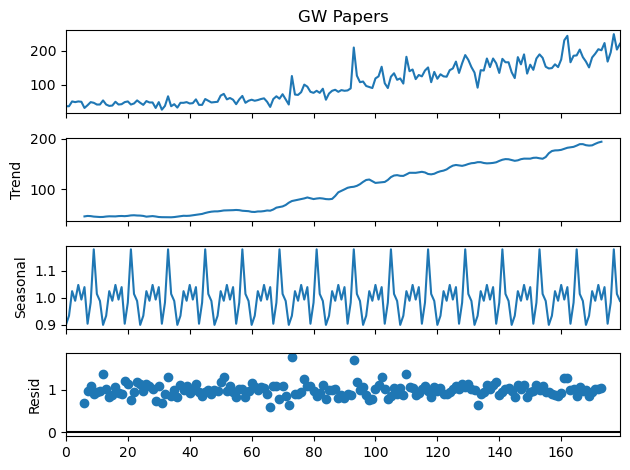

In [161]:
decomp_mult.plot()
plt.show()

We observe a clear upward trend in monthly GW publications, with a significant increase starting around 2015, coinciding with the first detection in September 2015. We also see a strong seasonal pattern, with peaks in publication activity occurring at regular intervals, likely corresponding to major conferences and publication cycles in the field, usually in the spring and fall.

## Control Group Comparison (GW Share)

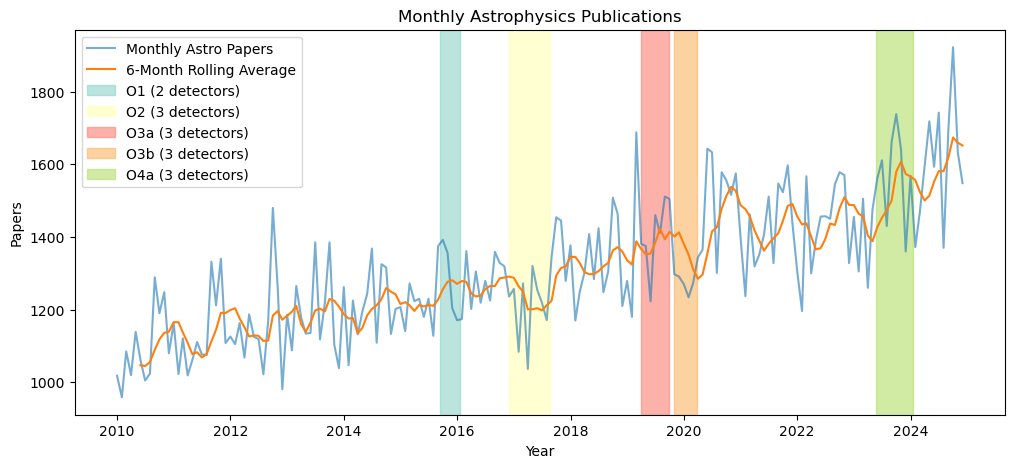

In [162]:
master["Rolling Astro Papers"] = master["Astro Papers"].rolling(6).mean()

plt.figure(figsize=(12,5))
plt.plot(master["Month"], master["Astro Papers"], alpha=0.6, label="Monthly Astro Papers")
plt.plot(master["Month"], master["Rolling Astro Papers"], label="6-Month Rolling Average")
colors = plt.cm.Set3(np.linspace(0, 1, len(runs)))
for idx, (_, row) in enumerate(runs.iterrows()):
    if row['Run'] <= current_data_lim:
        plt.axvspan(row["Start Date"], row["End Date"], alpha=0.6, color=colors[idx], label=f"{row['Run']} ({row['Detectors']} detectors)")
plt.title("Monthly Astrophysics Publications")
plt.legend()
plt.xlabel("Year")
plt.ylabel("Papers")
plt.show()

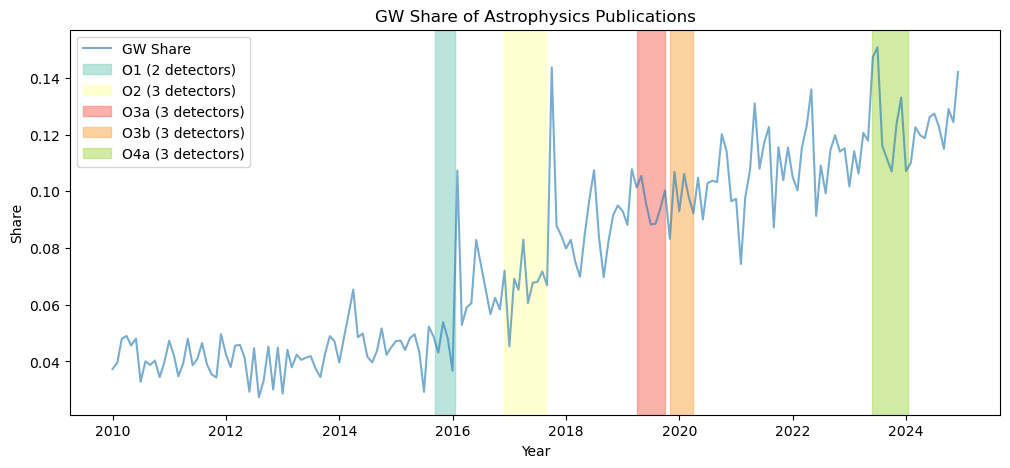

In [163]:
plt.figure(figsize=(12,5))
plt.plot(master["Month"], master["GW Share"], alpha=0.6, label="GW Share")
colors = plt.cm.Set3(np.linspace(0, 1, len(runs)))
for idx, (_, row) in enumerate(runs.iterrows()):
    if row['Run'] <= current_data_lim:
        plt.axvspan(row["Start Date"], row["End Date"], alpha=0.6, color=colors[idx], label=f"{row['Run']} ({row['Detectors']} detectors)")
plt.title("GW Share of Astrophysics Publications")
plt.legend(loc="upper left")
plt.xlabel("Year")
plt.ylabel("Share")
plt.show()

We see a clear upward trend in the share of GW publications within the broader astrophysics field, with significant increases following major detection runs. The plot also shows that the share of GW papers has grown substantially since the first detection in 2015.

The share plot highlights the growing relative importance of GW research compared to other astrophysics topics. While we see a clear upwards trend in astrophysics publications, the share of GW papers has increased more dramatically, suggesting that GW research is not only growing in absolute terms but also becoming a larger proportion of the overall astrophysics research landscape.

The shaded regions corresponding to different observation runs further highlight the correlation between detection activity and research output in this field.

## Pre vs Post 2015 Publication Shift

In [164]:
pre = master[master["Post_2015"] == 0]["GW Share"]
post = master[master["Post_2015"] == 1]["GW Share"]

t_stat, p_val = ttest_ind(pre, post, equal_var=False)

print("Pre/Post Publication Shift")
print("T-stat:", round(t_stat, 2))
print("P-value:", round(p_val, 5))

Pre/Post Publication Shift
T-stat: -22.02
P-value: 0.0


This comparison does not account for time trends, but it provides a simple snapshot of the significant increase in monthly GW publications following the first detection in September 2015. The t-test results indicate that the mean number of monthly publications post-2015 is significantly higher than the pre-2015 period, confirming that the first detection had a profound impact on research activity in this field.

With a t-statistic of -22.02, and a p-value of 0.00000, we have extremely strong evidence for a significant increase in monthly GW publications following the first detection in September 2015. The p-value indicates that the likelihood of observing such a large difference in publication rates by chance alone is effectively zero, confirming that the first detection had a profound and lasting impact on research activity in the field of gravitational wave astronomy.

## Regression Model: Publication boom following runs

In [165]:
master = pd.get_dummies(master, columns=["Phase"], dtype=int)

X = master[["Phase_Active", "Phase_Post_Run", "Time Index"]]
X = sm.add_constant(X)

y = master["GW Share"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               GW Share   R-squared:                       0.846
Model:                            OLS   Adj. R-squared:                  0.843
Method:                 Least Squares   F-statistic:                     322.1
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           3.23e-71
Time:                        16:13:27   Log-Likelihood:                 527.20
No. Observations:                 180   AIC:                            -1046.
Df Residuals:                     176   BIC:                            -1034.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0240      0.002     12.

While post-run months exhibit a modest increase in GW publication share, this effect is not statistically significant once long-term time trends are accounted for. The dominant driver of publication growth appears to be a sustained structural expansion of the field rather than discrete observation run phases.